# 02 - Modelos livianos para cierre causal

Este notebook muestra el avance actual del modelo de cierre antes de tener el RSV definitivo. Primero revisamos los datos, despues entrenamos candidatos livianos y recien al final comparamos metricas.

La entrada del modelo es `visible_context`: texto ruidoso acumulado desde el ultimo commit. La etiqueta es `wait`, `commit` o `low_confidence`.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from segmentacion_oraciones.src.notebook_reports import (
    card_grid,
    note_box,
    default_training_inputs,
    examples_overview,
    ensure_training_summary,
    candidate_frame,
)
from segmentacion_oraciones.src.cierre_ml import load_training_examples

pd.set_option('display.max_colwidth', 100)
OUT = Path('segmentacion_oraciones/outputs/notebooks/02_modelos_livianos')
OUT.mkdir(parents=True, exist_ok=True)
inputs = default_training_inputs()
inputs

['segmentacion_oraciones/ground_truth',
 'C:\\Users\\bianc\\Downloads\\synthetic_sentence_boundary_es_ar_v3_curated.zip']

## Datos usados

Si existe el ZIP sint?tico curado en `Downloads`, se suma automaticamente al ground truth real. Si no, el notebook sigue funcionando solo con `segmentacion_oraciones/ground_truth`.

In [2]:
overview = examples_overview(inputs)
display(card_grid([
    ('ejemplos', f"{overview['examples']:,}", 'filas causales'),
    ('fuentes', f"{overview['sources']:,}", 'source_id distintos'),
    ('wait', f"{overview['actions'].get('wait', 0):,}", None),
    ('commit', f"{overview['actions'].get('commit', 0):,}", None),
    ('low confidence', f"{overview['actions'].get('low_confidence', 0):,}", None),
]))

display(pd.DataFrame([{'grupo': 'synthetic', **overview['synthetic']}]))
display(pd.DataFrame(sorted(overview['splits'].items()), columns=['split_origen','ejemplos']))

,grupo,False,True
0,synthetic,233,11600


,split_origen,ejemplos
0,dev_synthetic_hard,2080
1,real_ground_truth,233
2,test_synthetic_noise,880
3,train_synthetic_curated,8640


## Ejemplos causales

Cada fila ya esta flattened para entrenamiento: lo que ve el modelo en ese instante y la accion esperada.

In [3]:
examples = load_training_examples(inputs)
sample_rows = []
for ex in examples[:6]:
    sample_rows.append({
        'source_id': ex.source_id,
        'clip_id': ex.clip_id,
        'action': ex.expected_action,
        'synthetic': ex.synthetic,
        'noise_level': ex.metadata.get('noise_level',''),
        'visible_context': ex.partial_text,
    })
display(pd.DataFrame(sample_rows))

,source_id,clip_id,action,synthetic,noise_level,visible_context
0,CHARLA SOBRE EL AMOR Y EL DESAMOR,clip_0000,commit,False,,voy a antereccionar maria del cerro y ahora que hay un monton de gente en el chat les quiero dec...
1,CHARLA SOBRE EL AMOR Y EL DESAMOR,clip_0001,wait,False,,la vida aca voy a aparecer un hippie o esas finas que leen el horoscopo
2,CHARLA SOBRE EL AMOR Y EL DESAMOR,clip_0002,commit,False,,la vida aca voy a aparecer un hippie o esas finas que leen el horoscopo pero la vida posta que s...
3,CHARLA SOBRE EL AMOR Y EL DESAMOR,clip_0003,wait,False,,entienden que estamos haciendo un stream a las 4 de la mañana en españa y tengo 24k de viewers h...
4,CHARLA SOBRE EL AMOR Y EL DESAMOR,clip_0004,commit,False,,entienden que estamos haciendo un stream a las 4 de la mañana en españa y tengo 24k de viewers h...
5,CHARLA SOBRE EL AMOR Y EL DESAMOR,clip_0005,wait,False,,yo ya tengo 10 11 años de streamer no me interesa ranquear pero te la blanqueo


## Entrenamiento local

Se comparan modelos baratos que corren sin GPU:

- `majority`: clase mayoritaria.
- `heuristic`: reglas conservadoras actuales.
- `linear_text`: clasificador lineal con features textuales y ruido.
- `linear_text_balanced`: version con balanceo por clase.
- `linear_heuristic`: texto + salida/razon de la heuristica como features.
- `linear_heuristic_balanced`: version balanceada.

In [4]:
summary = ensure_training_summary(inputs, OUT / 'training', seed=13)
display(card_grid([
    ('train', f"{summary['splits']['train']:,}", 'ejemplos'),
    ('val', f"{summary['splits']['val']:,}", 'ejemplos'),
    ('test', f"{summary['splits']['test']:,}", 'ejemplos'),
    ('ganador', summary['best']['best_name'], summary['best']['selection_metric']),
]))
display(note_box(f"Modelo elegido: <b>{summary['best']['best_name']}</b>. commit_f1={summary['best']['commit_f1']:.3f}, premature_commit_rate={summary['best']['premature_commit_rate']:.4f}.", kind='ok'))

## Comparacion de metricas

Esta seccion va al final a proposito: primero entendemos datos y tarea, despues miramos la tabla comparativa.

,modelo,selection_score,commit_f1,commit_precision,commit_recall,premature_commit_rate,low_confidence_recall,boundary_p95_abs,latency_p50_ms
0,linear_heuristic,1.0789,0.9880,0.9980,0.9782,0.0008,0.1948,0,0.1020
1,linear_heuristic_balanced,1.0728,0.9803,0.9727,0.9881,0.0111,0.4286,0,0.0805
2,linear_text,1.0671,0.9788,0.9979,0.9604,0.0008,0.2078,0,0.0603
3,linear_text_balanced,1.0353,0.9531,0.9811,0.9267,0.0071,0.4935,0,0.0688
4,heuristic,0.2594,0.5310,0.3615,1.0000,0.7063,0.0000,2,0.0340
5,majority,-0.1518,0.0000,0.0000,0.0000,0.0000,0.0000,0,0.0011


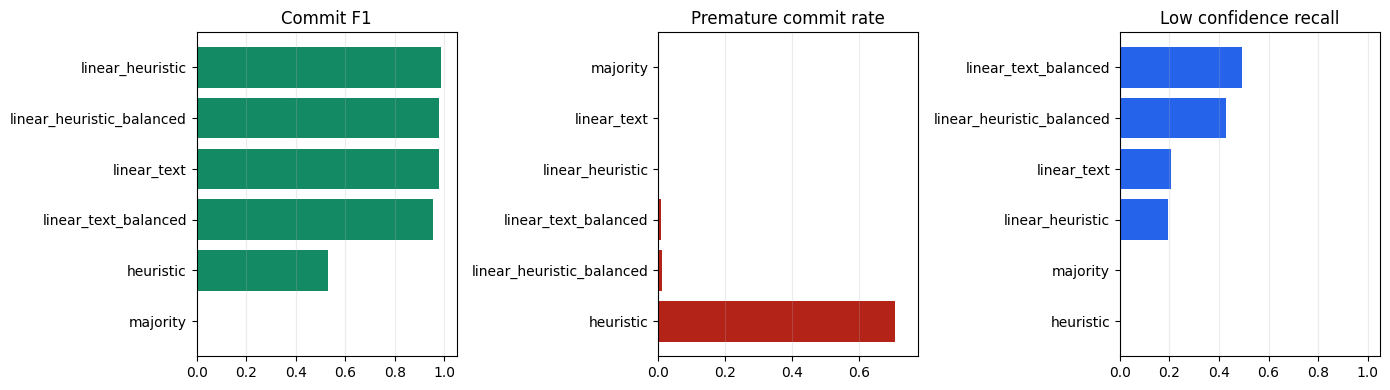

In [5]:
metrics = candidate_frame(summary, split='val')
display(metrics.style.format({
    'selection_score': '{:.4f}',
    'commit_f1': '{:.4f}',
    'commit_precision': '{:.4f}',
    'commit_recall': '{:.4f}',
    'premature_commit_rate': '{:.4f}',
    'low_confidence_recall': '{:.4f}',
    'latency_p50_ms': '{:.4f}',
}))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
ordered = metrics.sort_values('commit_f1')
axes[0].barh(ordered['modelo'], ordered['commit_f1'], color='#138a63')
axes[0].set_title('Commit F1')
axes[0].set_xlim(0, 1.05)
ordered = metrics.sort_values('premature_commit_rate', ascending=False)
axes[1].barh(ordered['modelo'], ordered['premature_commit_rate'], color='#b42318')
axes[1].set_title('Premature commit rate')
axes[1].set_xlim(0, max(0.05, ordered['premature_commit_rate'].max() * 1.1))
ordered = metrics.sort_values('low_confidence_recall')
axes[2].barh(ordered['modelo'], ordered['low_confidence_recall'], color='#2563eb')
axes[2].set_title('Low confidence recall')
axes[2].set_xlim(0, 1.05)
for ax in axes:
    ax.grid(axis='x', alpha=.25)
plt.tight_layout()
plt.show()

## Lectura

El clasificador lineal con features de heuristica es el mejor equilibrio actual. Los modelos balanceados levantan `low_confidence_recall`, pero sacrifican algo de commit. Cuando llegue RSV real, esta comparacion se repite por dominio real y no solo sobre sint?tico ruidoso.